<a href="https://colab.research.google.com/github/sabbirpuspo/LearningforMe/blob/main/Cybersecurity_Intrusion_Detection_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/SkillMorph Datasets/cybersecurity_intrusion_data.csv')
print(f"Shape: {df.shape}")
df.head()

Mounted at /content/drive
Shape: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [3]:
import os

drive_path = '/content/drive/MyDrive/SkillMorph Datasets/'
if os.path.exists(drive_path):
    print(f"Contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"The directory '{drive_path}' does not exist or is not accessible.")



Contents of '/content/drive/MyDrive/SkillMorph Datasets/':
diabetes.csv
StudentsPerformance.csv
gym_membership.csv
Housing.csv
cybersecurity_intrusion_data.csv
dataset_with_all_features v2.csv


In [10]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
print("\nAttack Detection Labels:\n", df['attack_detected'].value_counts().sort_index())
print("\nNote: The 'attack_detected' column is binary (0 or 1)")

Missing values per column:
 encryption_used    1966
dtype: int64

Attack Detection Labels:
 attack_detected
0    5273
1    4264
Name: count, dtype: int64

Note: The 'attack_detected' column is binary (0 or 1)


In [13]:
# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Drop session_id as it's an identifier and not a feature for scaling
df_processed = df.drop(columns=['session_id'])

# Separate features (X) and target (y)
X = df_processed.drop(columns=['attack_detected'])
y = df_processed['attack_detected']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Scale the features
X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20,stratify=y)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 7629 | Test: 1908


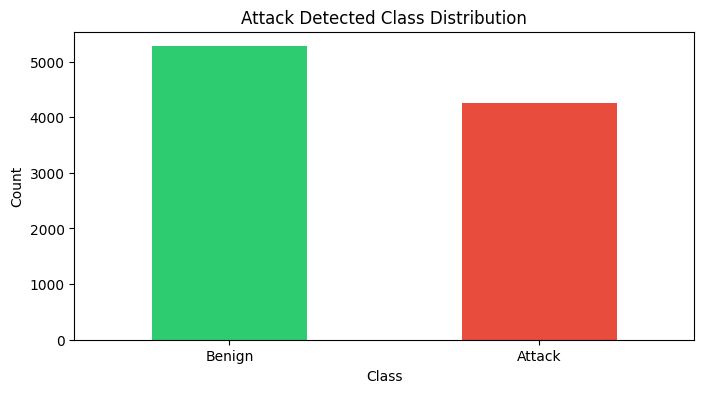

In [15]:
labels = ['Benign', 'Attack'] # Changed to reflect binary target

counts = df['attack_detected'].value_counts().sort_index() # Changed 'label' to 'attack_detected'

fig, ax = plt.subplots(figsize=(8, 4))

counts.plot.bar(
    ax=ax,
    color=['#2ecc71', '#e74c3c'] # Adjusted colors for two classes
)

ax.set_xticklabels(labels, rotation=0)
ax.set_title('Attack Detected Class Distribution') # Updated title
ax.set_xlabel('Class')
ax.set_ylabel('Count')

plt.show()

In [16]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=20)
}
results, predictions = {}, {}

for name, m in models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    predictions[name] = yp
    results[name] = {
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall':    recall_score(y_test, yp, average='weighted'),
        'F1-Score':  f1_score(y_test, yp, average='weighted')
    }
    print(f"{name}: Acc={results[name]['Accuracy']:.4f}  Precision = {results[name]['Precision']:.4f} Recall = {results[name]['Recall']:.4f} F1={results[name]['F1-Score']:.4f}")


Decision Tree: Acc=0.8155  Precision = 0.8169 Recall = 0.8155 F1=0.8158
KNN (k=5): Acc=0.8029  Precision = 0.8137 Recall = 0.8029 F1=0.7982
Logistic Reg: Acc=0.7495  Precision = 0.7488 Recall = 0.7495 F1=0.7487


           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8747     0.8979  0.8747    0.8709
5            0.8947     0.9115  0.8947    0.8922
10           0.8952     0.9090  0.8952    0.8930
15           0.8800     0.8868  0.8800    0.8783
20           0.8595     0.8607  0.8595    0.8587
None         0.8155     0.8169  0.8155    0.8158


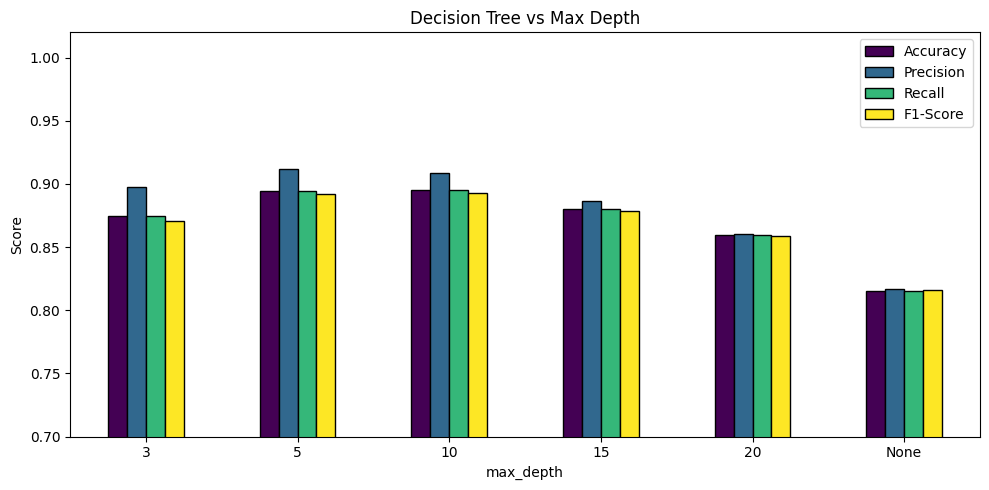

In [17]:
dt_results = []
for d in [3, 5, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=20).fit(X_train, y_train)
    yp = dt.predict(X_test)
    dt_results.append({'max_depth': str(d) or 'None',
        'Accuracy': accuracy_score(y_test, yp), 'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'), 'F1-Score': f1_score(y_test, yp, average='weighted')})

dt_df = pd.DataFrame(dt_results).set_index('max_depth')
print(dt_df.round(4))
dt_df.plot(kind='bar', figsize=(10,5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree vs Max Depth'); plt.ylabel('Score'); plt.ylim(0.7, 1.02); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [19]:
target_names = ['Benign', 'Attack'] # Changed to match the 2 classes (0 and 1) in attack_detected
for name, yp in predictions.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, yp, target_names=target_names, digits=4))


Decision Tree
              precision    recall  f1-score   support

      Benign     0.8463    0.8142    0.8300      1055
      Attack     0.7805    0.8171    0.7984       853

    accuracy                         0.8155      1908
   macro avg     0.8134    0.8157    0.8142      1908
weighted avg     0.8169    0.8155    0.8158      1908


KNN (k=5)
              precision    recall  f1-score   support

      Benign     0.7692    0.9194    0.8377      1055
      Attack     0.8686    0.6589    0.7493       853

    accuracy                         0.8029      1908
   macro avg     0.8189    0.7891    0.7935      1908
weighted avg     0.8137    0.8029    0.7982      1908


Logistic Reg
              precision    recall  f1-score   support

      Benign     0.7620    0.7953    0.7783      1055
      Attack     0.7323    0.6928    0.7120       853

    accuracy                         0.7495      1908
   macro avg     0.7472    0.7441    0.7452      1908
weighted avg     0.7488    0.7495 

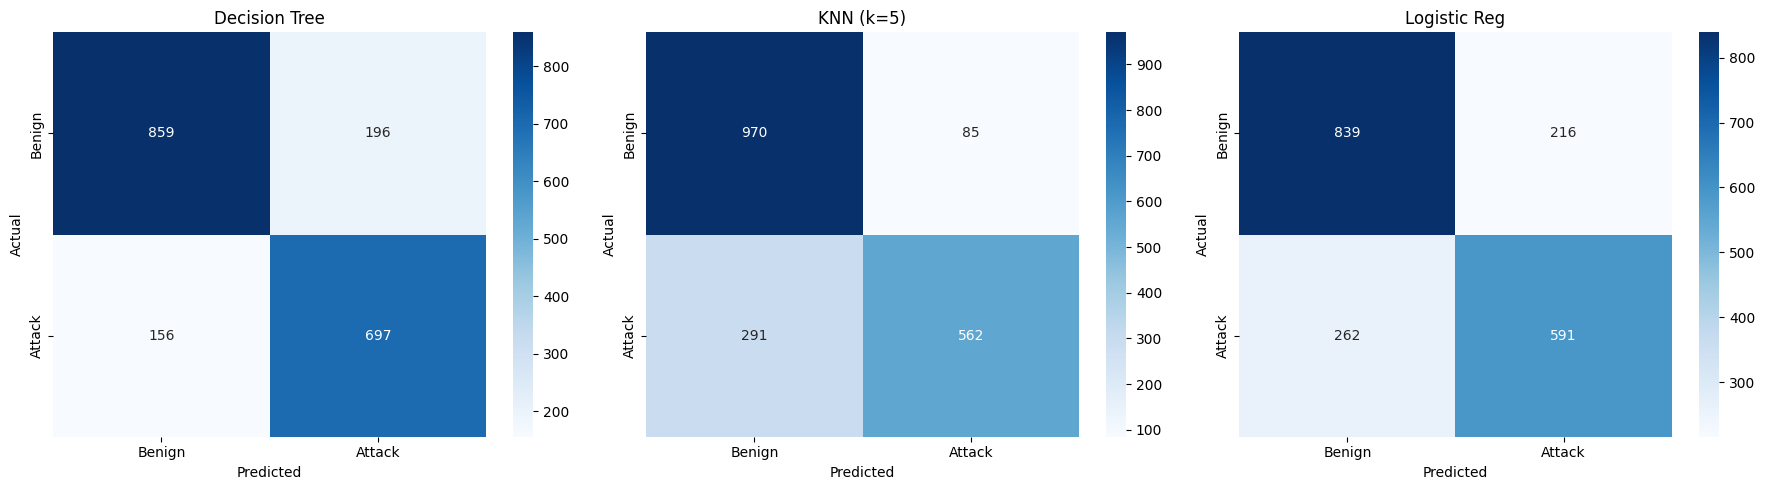

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

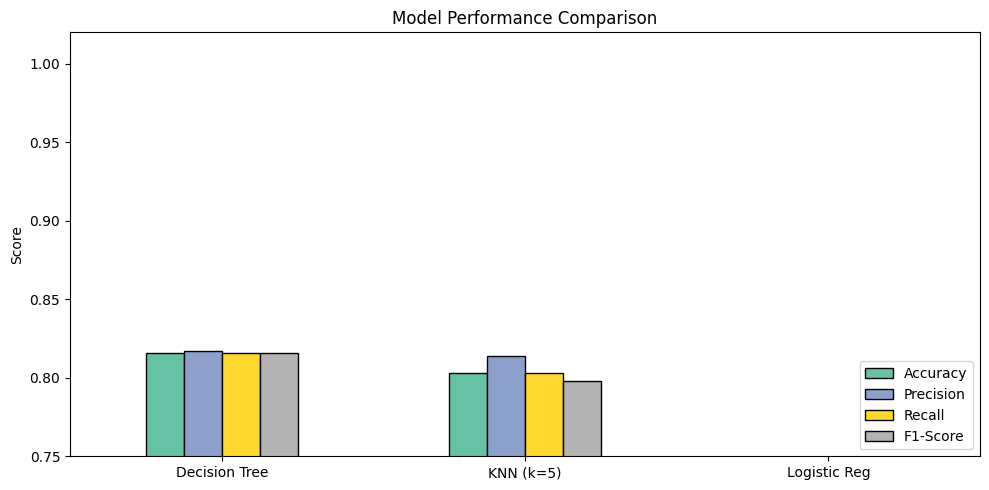


Summary:
                Accuracy  Precision  Recall  F1-Score
Decision Tree    0.8155     0.8169  0.8155    0.8158
KNN (k=5)        0.8029     0.8137  0.8029    0.7982
Logistic Reg     0.7495     0.7488  0.7495    0.7487


In [21]:
res_df = pd.DataFrame(results).T
res_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison'); plt.ylabel('Score'); plt.ylim(0.75, 1.02)
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print("\nSummary:\n", res_df.round(4))